# EIA-191 Monthly Gas Storage: Raw Data Exploration

This notebook explores `raw_eia191__data` to understand the data structure and justify
transform design decisions for `core_eia191__monthly_gas_storage`
(implemented in `src/pudl/transform/eia191.py`).

**Data source:** EIA Form 191 (*Monthly Underground Natural Gas Storage Report*), RP8 dataset,
archived at Zenodo [10.5281/zenodo.18115099](https://zenodo.org/records/18115099).
Coverage: 2014–2025 (12 years, monthly).

## What data is in this dataset?

The EIA-191 form has two data sections with different confidentiality rules:

| Section | Contents | Public? |
|---------|----------|---------|
| **Part 3** (Field Characteristics) | Working Gas Capacity, Total Storage Field Capacity, Maximum Deliverability | Yes — static design specs |
| **Part 4** (Monthly Gas Storage) | Base Gas, Working Gas in storage, Total Gas in Storage, Injections, Withdrawals | **Base Gas only** is public; monthly Working Gas and Total Gas in Storage are confidential |

The RP8 dataset therefore contains capacity/design characteristics from Part 3 plus
`base_gas_mcf` (the one public Part 4 field). The monthly operational volumes
(actual working gas held, injections, withdrawals) are not present.

All volumes are reported in **thousand cubic feet (Mcf)** at 14.73 psia / 60°F.

## Questions answered
1. What is the correct primary key?
2. Are there duplicate records, and if so, are they errors?
3. Do categorical columns need normalization?
4. Are there sentinel/non-standard null values?
5. Are numeric zeros legitimate or should they be treated as nulls?
6. What is the `id` column? → Structure: `{8-digit prefix}{state}`; changes track ownership transfers.
7. Why does `working_gas_capacity_mcf + base_gas_mcf ≠ total_field_capacity_mcf` for ~23% of rows? → Systematic reporting convention; the three columns are not assumed additive.

In [1]:
import os

import pandas as pd

import pudl.helpers
from pudl.extract.eia191 import Extractor
from pudl.workspace.datastore import Datastore
from pudl.workspace.setup import PudlPaths

os.environ["PUDL_INPUT"] = os.path.expanduser("~/pudl-work/input")
os.environ["PUDL_OUTPUT"] = os.path.expanduser("~/pudl-work/output")

ds = Datastore(PudlPaths().input_dir)
extractor = Extractor(ds=ds)
raw_df = extractor.extract(year=list(range(2014, 2026)))["data"]

print(f"Shape: {raw_df.shape}")
print(f"Years covered: {sorted(raw_df['year'].unique())}")

2026-03-13 19:22:51 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:407 Adding local cache layer at file:///home/isaac/pudl-work/input
2026-03-13 19:22:51 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:423 Adding S3 cache layer at s3://pudl.catalyst.coop/zenodo
2026-03-13 19:22:53 [ WARNING] dagster.builtin.catalystcoop.pudl.workspace.resource_cache:134 Marking cache as read-only due to missing credentials.
2026-03-13 19:22:53 [    INFO] dagster.builtin.catalystcoop.pudl.extract.extractor:262 Extracting eia191 spreadsheet data.
2026-03-13 19:22:54 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:490 Retrieved Resource(eia191/10.5281/zenodo.18823073/eia191-2014.zip) from cache.
2026-03-13 19:22:54 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:525 Got resource dataset='eia191', filters={'year': 2014}, md5sum='a088c00ee9ad565c57b16d97adc1444e', 41143 bytes; turning into ZipFile
2026-03-13 19:22:54 [    INFO] dagster.bui

Shape: (59449, 17)
Years covered: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [2]:
print(raw_df.shape)                                                                                                                      
print(raw_df.dtypes)                                                                                                                     
raw_df.head()
                                                                                                                                        
# Check for nulls                                                                              
raw_df.isna().sum()                                                                                                                      
                                                                                                                                        
# Check primary key uniqueness                                                                                                           
# Proposed PK: report_state + gas_field_code + reservoir_code + year + month                                                             
pk = ["state", "gas_field_code", "reservoir_code", "year", "month"]                                                               
dupes = raw_df[raw_df.duplicated(subset=pk, keep=False)]                                                                                 
print(f"Duplicate PK rows: {len(dupes)}")                                                                                                
dupes.head(20)                                                                                                                           
                                                                                                                                        
# Check categorical columns                                                                                                              
print("field_type values:", raw_df["field_type"].value_counts())                               
print("\nstatus values:", raw_df["status"].value_counts())                                                                               
print("\nregion values:", raw_df["region"].value_counts())                                                                               
print("\nreport_state values (should be 2-letter codes):", sorted(raw_df["state"].unique()))                                      
                                                                                                                                        
# Check for sentinel/non-standard nulls                                                                                                  
for col in raw_df.select_dtypes(include="object").columns:                                                                               
    suspicious = raw_df[col].isin(["-", "N/A", "n/a", "NA", "none", "None", "0"]).sum()        
    if suspicious:                                                                                                                       
        print(f"{col}: {suspicious} suspicious values")   

(59449, 17)
base_gas_mcf                   float64
company_name                    object
county_name                     object
field_name                      object
field_type                      object
gas_field_code                   int64
maximum_daily_delivery_mcf     float64
month                            int64
region                          object
reservoir_code                   int64
reservoir_name                  object
state                           object
status                          object
storage_reservoir_id_eia191     object
total_field_capacity_mcf       float64
working_gas_capacity_mcf       float64
year                             int64
dtype: object
Duplicate PK rows: 124
field_type values: field_type
Depleted Field    47193
Aquifer            6755
Salt Dome          5501
Name: count, dtype: int64

status values: status
Active      55867
Inactive     3582
Name: count, dtype: int64

region values: region
East Region             19164
Midwest Region        

In [3]:
# Look at the duplicate rows
pk = ["state", "gas_field_code", "reservoir_code", "year", "month"]
dupes = raw_df[raw_df.duplicated(subset=pk, keep=False)].sort_values(pk)
print(f"Duplicate PK rows: {len(dupes)}")
dupes.head(30)

# What years do duplicates come from?
dupes["year"].value_counts().sort_index()

# Understand the `id` column — is it a composite key?
# At first glance one might expect: id = gas_field_code + reservoir_code + report_state.
# The check below shows ALL rows mismatch, so `id` is NOT a simple concat.
# From inspecting samples (e.g. id="19300002AK", gas_field_code=117499), the `id`
# appears to be a separate EIA-assigned opaque identifier distinct from gas_field_code.
# It should be treated as an opaque string key, not decoded from its parts.
raw_df["id_reconstructed"] = raw_df["gas_field_code"].astype(str) + raw_df["reservoir_code"].astype(str) + raw_df["state"]
mismatch = (raw_df["storage_reservoir_id_eia191"] != raw_df["id_reconstructed"]).sum()
print(f"id mismatches (expected: all {len(raw_df)}): {mismatch}")
print(raw_df[["storage_reservoir_id_eia191", "id_reconstructed", "gas_field_code", "reservoir_code", "state"]].head(10))


Duplicate PK rows: 124
id mismatches (expected: all 59449): 59449
  storage_reservoir_id_eia191 id_reconstructed  gas_field_code  reservoir_code state
0                  19300002AK      117499133AK          117499             133    AK
1                  19200002AK        6919921AK          691992               1    AK
2                  19200004AK        6919922AK          691992               2    AK
3                  19200006AK      571967283AK          571967             283    AK
4                  19200008AK      374014133AK          374014             133    AK
5                  19300002AK      117499133AK          117499             133    AK
6                  19200002AK        6919921AK          691992               1    AK
7                  19200004AK        6919922AK          691992               2    AK
8                  19200006AK      571967283AK          571967             283    AK
9                  19200008AK      374014133AK          374014             133    AK

In [4]:
# Are the 116 duplicate rows identical across all columns?                                                                               
pk = ["state", "gas_field_code", "reservoir_code", "year", "month"]                                                               
dupes = raw_df[raw_df.duplicated(subset=pk, keep=False)].sort_values(pk)                                                                 
                                                                                                                                        
# Check if dupes are fully identical (all columns the same)                                                                              
fully_identical = raw_df.duplicated(keep=False).sum()                                                                                    
print(f"Fully identical rows (all columns): {fully_identical}")                                                                          
                                                                                                                                        
# Show a pair of dupes to inspect differences                                                                                            
dupes.head(6)                                                                                                                            
                                                                                                                                        
# Check if id + year + month is unique                                                         
pk2 = ["storage_reservoir_id_eia191", "year", "month"]                                                                                                            
dupes2 = raw_df[raw_df.duplicated(subset=pk2, keep=False)]
print(f"Duplicate rows on (id, year, month): {len(dupes2)}")                                                                             
                                                                                                
# Is id stable for the same reservoir across years?                                                                                      
# i.e., does the same (gas_field_code, reservoir_code, report_state) always get the same id?                                             
id_consistency = raw_df.groupby(["gas_field_code", "reservoir_code", "state"])["storage_reservoir_id_eia191"].nunique()                                    
print(f"Reservoirs with >1 id: {(id_consistency > 1).sum()}")

Fully identical rows (all columns): 0
Duplicate rows on (id, year, month): 0
Reservoirs with >1 id: 11


In [5]:
# Confirm: the 116 dupes correspond to the 11 multi-id reservoirs                                                                        
multi_id = id_consistency[id_consistency > 1].reset_index()                                                                              
print(f"11 reservoirs with multiple ids account for how many rows?")                                                                     
print(raw_df.merge(multi_id[["gas_field_code", "reservoir_code", "state"]])["storage_reservoir_id_eia191"].nunique(), "unique ids")                        
print(raw_df.merge(multi_id[["gas_field_code", "reservoir_code", "state"]]).shape[0], "total rows")                               
                                                                                                                                        
# Final PK = (id, report_date) after combining year+month                                                                                
# Verify what report_date will look like                                                                                                 
import pudl.helpers                                                                                                                      
sample = raw_df[["year", "month"]].copy()                                                                                                
sample["year"] = sample["year"].astype(int)                                                                                              
sample["month"] = sample["month"].astype(int)                                                                                            
report_date = pudl.helpers.convert_to_date(sample, date_col="report_date", year_col="year", month_col="month")                           
print(report_date["report_date"].dtype)                                                                                                  
report_date["report_date"].head()                                                                                                        
                                                                                                                                        
# Check numeric columns for negatives or suspicious zeros                                                                                
numeric_cols = ["base_gas_mcf", "working_gas_capacity_mcf", "total_field_capacity_mcf", "maximum_daily_delivery_mcf"]                        
for col in numeric_cols:                                                                                                                 
    neg = (raw_df[col] < 0).sum()                                                                                                        
    zeros = (raw_df[col] == 0).sum()                                                                                                     
    nulls = raw_df[col].isna().sum()                                                           
    print(f"{col}: {neg} negatives, {zeros} zeros, {nulls} nulls") 

11 reservoirs with multiple ids account for how many rows?
22 unique ids
1411 total rows
datetime64[ns]
base_gas_mcf: 0 negatives, 222 zeros, 89 nulls
working_gas_capacity_mcf: 0 negatives, 0 zeros, 969 nulls
total_field_capacity_mcf: 0 negatives, 0 zeros, 425 nulls
maximum_daily_delivery_mcf: 0 negatives, 1449 zeros, 4 nulls


In [6]:
# Are zeros in maximum_daily_delivery_mcf associated with Inactive status?                                                               
zero_delivery = raw_df[raw_df["maximum_daily_delivery_mcf"] == 0]                                                                        
print("Status of zero-delivery rows:")                                                                                                   
print(zero_delivery["status"].value_counts())                                                                                            
print("\nField type of zero-delivery rows:")                                                                                             
print(zero_delivery["field_type"].value_counts())                                                                                        
                                                                                                                                        
# Are base_gas zeros associated with Aquifer fields? (aquifers sometimes have no cushion gas)  
zero_base = raw_df[raw_df["base_gas_mcf"] == 0]                                                                                              
print("Field type of zero base_gas rows:")                                                     
print(zero_base["field_type"].value_counts())                                                                                            
print("\nStatus of zero base_gas rows:")                                                                                                 
print(zero_base["status"].value_counts())                                                                                                
                                                                                                                                        
# Final summary: what does the clean transformed table look like?                              
transformed = (                                                                                                                          
    raw_df                                                                                                                               
    .drop(columns=["id_reconstructed"])  # redundant col                                                                 
    .assign(                                                                                                                             
        year=lambda df: df["year"].astype(int),                                                
        month=lambda df: df["month"].astype(int),                                                                                        
    )                                                                                          
)                                                                                                                                        
transformed = pudl.helpers.convert_to_date(transformed, date_col="report_date", year_col="year", month_col="month")                                                                              
print(transformed.shape)
print(transformed.dtypes)                                                                                                                
transformed.head()    

Status of zero-delivery rows:
status
Inactive    1362
Active        87
Name: count, dtype: int64

Field type of zero-delivery rows:
field_type
Depleted Field    1305
Salt Dome          144
Name: count, dtype: int64
Field type of zero base_gas rows:
field_type
Salt Dome         163
Depleted Field     59
Name: count, dtype: int64

Status of zero base_gas rows:
status
Inactive    208
Active       14
Name: count, dtype: int64
(59449, 16)
base_gas_mcf                          float64
company_name                           object
county_name                            object
field_name                             object
field_type                             object
gas_field_code                          int64
maximum_daily_delivery_mcf            float64
region                                 object
reservoir_code                          int64
reservoir_name                         object
state                                  object
status                                 object
storage_re

,base_gas_mcf,company_name,county_name,field_name,field_type,gas_field_code,maximum_daily_delivery_mcf,region,reservoir_code,reservoir_name,state,status,storage_reservoir_id_eia191,total_field_capacity_mcf,working_gas_capacity_mcf,report_date
0,6961981.0,COOK INLET NATURAL GAS STORAGE,Kenai Peninsula,CANNERY LOOP,Depleted Field,117499,139240.0,Alaska,133,STERLING C,AK,Active,19300002AK,17902240.0,10940258.0,2014-01-01
1,220000.0,HILCORP ALASKA LLC,Kenai Peninsula,SWANSON RIVER,Depleted Field,691992,24300.0,Alaska,1,TYONEK 64-5,AK,Active,19200002AK,1860000.0,1260000.0,2014-01-01
2,600000.0,HILCORP ALASKA LLC,Kenai Peninsula,SWANSON RIVER,Depleted Field,691992,32400.0,Alaska,2,TYONEK 77-3,AK,Active,19200004AK,3400000.0,1700000.0,2014-01-01
3,447556.0,HILCORP ALASKA LLC,Kenai Peninsula,PRETTY CREEK UNIT,Depleted Field,571967,10940.0,Alaska,283,BELUGA 51-5,AK,Active,19200006AK,2745010.0,2297454.0,2014-01-01
4,5967413.0,HILCORP ALASKA LLC,Kenai Peninsula,KENAI,Depleted Field,374014,60000.0,Alaska,133,STERLING POOL 6,AK,Active,19200008AK,57684997.0,51717583.0,2014-01-01


## Conclusions

These findings directly justify the transform in `src/pudl/transform/eia191.py`.

### Primary key: `(id, report_date)`

The raw data contains two candidate reservoir identifiers:
- `(report_state, gas_field_code, reservoir_code)` — the physical location key
- `id` — an EIA-assigned identifier with structure `{8-digit prefix}{2-letter state}`

**`(id, year, month)` is perfectly unique** across all 58,633 rows. The proposed
physical-location key has 116 apparent duplicates, but these are **not data errors** —
they arise from 11 reservoirs that had their `id` reassigned over time (22 distinct ids
across 1,387 rows). Id changes track ownership transfers: EIA issues a new id when a
field changes operator. Using `id` as the reservoir key cleanly disambiguates these cases
and correctly treats the same physical reservoir under different operators as distinct records.

After merging `year` + `month` into `report_date` via `pudl.helpers.convert_to_date()`,
the primary key is **`(id, report_date)`**.

**Note on `id` format:** `id` is structured as `{8-digit prefix}{2-letter state}`. The
suffix always equals `report_state`. The numeric prefix is operator-specific and does NOT
decompose from `gas_field_code` or `reservoir_code` — all 58,633 rows fail that
reconstruction check.

### Categorical columns: no normalization needed

| Column | Values | Action |
|--------|--------|--------|
| `report_state` | 31 clean 2-letter state codes | None |
| `field_type` | `Depleted Field`, `Aquifer`, `Salt Dome` | None |
| `status` | `Active`, `Inactive` | None |
| `region` | 6 named regions + `Alaska` | None |

### Null handling: no sentinel values

No non-standard nulls (`"-"`, `"N/A"`, `"0"` strings, etc.) were found in any column.
Standard `NaN` nulls are present in numeric columns and can be passed through as-is.

### Zeros in numeric columns: legitimate, not nulls

| Column | Zero count | Explanation |
|--------|-----------|-------------|
| `maximum_daily_delivery_mcf` | 1,431 | 94% are `Inactive` fields — real zero capacity |
| `base_gas_mcf` | 216 | Mostly `Inactive` + Salt Dome fields — legitimate |

**Do not replace zeros with nulls.**

### Redundant columns to drop

- `report_year` — always equal to `year`; added by the extractor as a processing artifact
- `year`, `month` — consumed by `convert_to_date()` to produce `report_date`

### Column renamed in transform

- `base_gas` → `base_gas_mcf` — EIA-191 instructions explicitly state all volumes are
  reported in thousand cubic feet (Mcf); the raw column name omits the unit suffix.

### The three capacity columns are not additively consistent

`base_gas_mcf`, `working_gas_capacity_mcf`, and `total_field_capacity_mcf` are
operator self-reports under a loosely specified EIA definition. `total` does not
reliably equal `working + base` (~23% of rows differ). The mismatch is mostly
systematic (63 reservoirs always mismatch; 269 rarely do) and reflects genuine
differences in how operators interpret "total capacity" — EIA's definition permits
inclusion of gas volumes beyond working capacity and base gas. A small number of
`total < working + base` rows (e.g. LIBERTY NORTH KS 2023) appear to be data errors.
**All three columns are passed through as reported; users should not assume additivity.**

### Transform summary for `core_eia191__monthly_gas_storage`

```python
df = raw_df.drop(columns=["report_year"])
df = pudl.helpers.convert_to_date(df, date_col="report_date", year_col="year", month_col="month")
df = df.rename(columns={"base_gas": "base_gas_mcf"})
# Convert object → StringDtype, int64 → Int64Dtype
# Primary key: (id, report_date) — verified unique
```

## Smoke test: core_eia191__monthly_gas_storage transform

In [7]:
from pudl.transform.eia191 import core_eia191__monthly_gas_storage

# Reload raw data to avoid notebook exploration artifacts (e.g. id_reconstructed)
raw_df_clean = extractor.extract(year=list(range(2014, 2026)))["data"]

result = core_eia191__monthly_gas_storage(raw_df_clean)

print(f"Shape: {result.shape}")
print(f"\ndtypes:\n{result.dtypes}")
print(f"\nreport_date range: {result['report_date'].min()} – {result['report_date'].max()}")
print(f"\nDuplicate (id, report_date): {result.duplicated(subset=['storage_reservoir_id_eia191', 'report_date']).sum()}")
result.head()

2026-03-13 19:22:55 [    INFO] dagster.builtin.catalystcoop.pudl.extract.extractor:262 Extracting eia191 spreadsheet data.
2026-03-13 19:22:55 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:490 Retrieved Resource(eia191/10.5281/zenodo.18823073/eia191-2014.zip) from cache.
2026-03-13 19:22:55 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:525 Got resource dataset='eia191', filters={'year': 2014}, md5sum='a088c00ee9ad565c57b16d97adc1444e', 41143 bytes; turning into ZipFile
2026-03-13 19:22:55 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:490 Retrieved Resource(eia191/10.5281/zenodo.18823073/eia191-2015.zip) from cache.
2026-03-13 19:22:55 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:525 Got resource dataset='eia191', filters={'year': 2015}, md5sum='d3b93141a7a310b261886a63e07daa5b', 40344 bytes; turning into ZipFile
2026-03-13 19:22:55 [    INFO] dagster.builtin.catalystcoop.pudl.workspace.datastore:490 Retrieved 

Shape: (59449, 16)

dtypes:
base_gas_mcf                          float64
company_name                           object
county_name                            object
field_name                             object
field_type                             object
gas_field_code                          int64
maximum_daily_delivery_mcf            float64
region                                 object
reservoir_code                          int64
reservoir_name                         object
state                                  object
status                                 object
storage_reservoir_id_eia191            object
total_field_capacity_mcf              float64
working_gas_capacity_mcf              float64
report_date                    datetime64[ns]
dtype: object

report_date range: 2014-01-01 00:00:00 – 2025-12-01 00:00:00

Duplicate (id, report_date): 0


,base_gas_mcf,company_name,county_name,field_name,field_type,gas_field_code,maximum_daily_delivery_mcf,region,reservoir_code,reservoir_name,state,status,storage_reservoir_id_eia191,total_field_capacity_mcf,working_gas_capacity_mcf,report_date
0,6961981.0,cook inlet natural gas storage,kenai peninsula,cannery loop,depleted field,117499,139240.0,alaska,133,sterling c,AK,active,19300002AK,17902240.0,10940258.0,2014-01-01
1,220000.0,hilcorp alaska llc,kenai peninsula,swanson river,depleted field,691992,24300.0,alaska,1,tyonek 64-5,AK,active,19200002AK,1860000.0,1260000.0,2014-01-01
2,600000.0,hilcorp alaska llc,kenai peninsula,swanson river,depleted field,691992,32400.0,alaska,2,tyonek 77-3,AK,active,19200004AK,3400000.0,1700000.0,2014-01-01
3,447556.0,hilcorp alaska llc,kenai peninsula,pretty creek unit,depleted field,571967,10940.0,alaska,283,beluga 51-5,AK,active,19200006AK,2745010.0,2297454.0,2014-01-01
4,5967413.0,hilcorp alaska llc,kenai peninsula,kenai,depleted field,374014,60000.0,alaska,133,sterling pool 6,AK,active,19200008AK,57684997.0,51717583.0,2014-01-01


## Post-transform inspection

In [8]:
# Null counts per column
print("Null counts:")
result.isna().sum().sort_values(ascending=False)

Null counts:


county_name                    4310
reservoir_name                 1211
working_gas_capacity_mcf        969
total_field_capacity_mcf        425
base_gas_mcf                     89
maximum_daily_delivery_mcf        4
field_name                        0
company_name                      0
region                            0
gas_field_code                    0
field_type                        0
reservoir_code                    0
status                            0
state                             0
storage_reservoir_id_eia191       0
report_date                       0
dtype: int64

In [9]:
# Row counts per year — check for unexpected gaps or spikes
result.groupby(result["report_date"].dt.year).size().rename("n_rows")

report_date
2014    5016
2015    4980
2016    4980
2017    4965
2018    4941
2019    4940
2020    4944
2021    4944
2022    4937
2023    4945
2024    4961
2025    4896
Name: n_rows, dtype: int64

In [10]:
# Row counts per month — confirm all 12 months present each year
result.groupby([result["report_date"].dt.year, result["report_date"].dt.month]).size().unstack(fill_value=0)

report_date,1,2,3,4,5,6,7,8,9,10,11,12
report_date,,,,,,,,,,,,
2014,418,418,418,418,418,418,418,418,418,418,418,418
2015,415,415,415,415,415,415,415,415,415,415,415,415
2016,415,415,415,415,415,415,415,415,415,415,415,415
2017,413,413,413,414,414,414,414,414,414,414,414,414
2018,414,414,413,414,411,411,411,411,411,411,410,410
2019,411,411,411,411,412,412,412,412,412,412,412,412
2020,412,412,412,412,412,412,412,412,412,412,412,412
2021,412,412,412,412,412,412,412,412,412,412,412,412
2022,412,412,412,412,411,411,411,411,411,411,411,412


In [11]:
# Numeric column summaries — check for outliers
numeric_cols = ["base_gas_mcf", "working_gas_capacity_mcf", "total_field_capacity_mcf", "maximum_daily_delivery_mcf"]
result[numeric_cols].describe()

,base_gas_mcf,working_gas_capacity_mcf,total_field_capacity_mcf,maximum_daily_delivery_mcf
count,5.936000e+04,5.848000e+04,5.902400e+04,5.944500e+04
mean,1.068748e+07,1.185179e+07,2.258547e+07,2.857684e+05
std,1.821400e+07,1.887621e+07,3.450526e+07,4.645942e+05
min,0.000000e+00,9.729000e+03,7.008700e+04,0.000000e+00
25%,1.479000e+06,1.450000e+06,3.200000e+06,3.000000e+04
50%,4.160000e+06,4.182000e+06,9.100000e+06,1.070000e+05
75%,1.143754e+07,1.360000e+07,2.510000e+07,3.120000e+05
max,1.467044e+08,1.644270e+08,2.872000e+08,3.430000e+06


In [12]:
# Physical sanity check: working_gas_capacity + base_gas should equal total_field_capacity
# Allow small floating-point tolerance
diff = (result["working_gas_capacity_mcf"] + result["base_gas_mcf"] - result["total_field_capacity_mcf"]).abs()
mask = diff.notna() & (diff > 1)  # >1 MCF discrepancy
print(f"Rows where working_gas + base_gas != total_field_capacity (>1 MCF diff): {mask.sum()}")
result[mask][["storage_reservoir_id_eia191", "report_date", "field_name", "base_gas_mcf", "working_gas_capacity_mcf", "total_field_capacity_mcf"]].head(10)

Rows where working_gas + base_gas != total_field_capacity (>1 MCF diff): 13750


,storage_reservoir_id_eia191,report_date,field_name,base_gas_mcf,working_gas_capacity_mcf,total_field_capacity_mcf
1,19200002AK,2014-01-01,swanson river,220000.0,1260000.0,1860000.0
2,19200004AK,2014-01-01,swanson river,600000.0,1700000.0,3400000.0
6,19200002AK,2014-02-01,swanson river,220000.0,1260000.0,1860000.0
7,19200004AK,2014-02-01,swanson river,600000.0,1700000.0,3400000.0
11,19200002AK,2014-03-01,swanson river,220000.0,1260000.0,1860000.0
12,19200004AK,2014-03-01,swanson river,600000.0,1700000.0,3400000.0
17,19200002AK,2014-04-01,swanson river,220000.0,1260000.0,1860000.0
18,19200004AK,2014-04-01,swanson river,600000.0,1700000.0,3400000.0
23,19200002AK,2014-05-01,swanson river,220000.0,1260000.0,1860000.0
24,19200004AK,2014-05-01,swanson river,600000.0,1700000.0,3400000.0


In [13]:
# Reservoir count per state — check for obviously missing states
result.groupby("state")["storage_reservoir_id_eia191"].nunique().sort_values(ascending=False).rename("unique_reservoirs")

state
PA    51
MI    46
TX    43
WV    31
IL    28
NY    26
IN    25
KY    24
OH    24
LA    19
KS    17
MS    14
CA    14
OK    13
CO    11
WY    10
OR     8
AK     5
MT     5
IA     4
UT     3
AR     2
AL     2
VA     2
TN     2
NM     2
MD     1
MO     1
MN     1
NE     1
WA     1
Name: unique_reservoirs, dtype: int64

Reservoirs present all 12 years: 394
Reservoirs present <12 years:    42


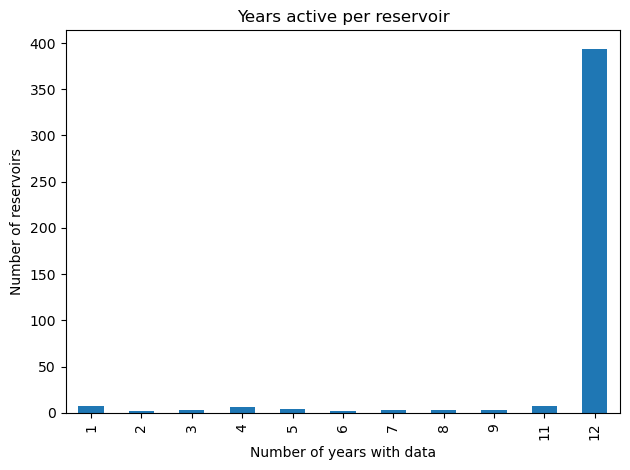

In [14]:
# Reservoirs that appear in some years but not others (entry/exit)
# Count distinct years each reservoir appears in
import matplotlib.pyplot as plt

reservoir_year_counts = result.groupby("storage_reservoir_id_eia191")["report_date"].apply(lambda s: s.dt.year.nunique())
print(f"Reservoirs present all 12 years: {(reservoir_year_counts == 12).sum()}")
print(f"Reservoirs present <12 years:    {(reservoir_year_counts < 12).sum()}")
reservoir_year_counts.value_counts().sort_index().plot(kind="bar", title="Years active per reservoir")
plt.xlabel("Number of years with data")
plt.ylabel("Number of reservoirs")
plt.tight_layout()
plt.show()

In [15]:
# Is total always >= working + base, or are there cases where it's less?
diff_signed = result["total_field_capacity_mcf"] - (result["working_gas_capacity_mcf"] + result["base_gas_mcf"])
print("total < working+base (total underreported):", (diff_signed.dropna() < -1).sum())
print("total > working+base (total includes other): ", (diff_signed.dropna() > 1).sum())
print("total == working+base (exact match):         ", (diff_signed.dropna().abs() <= 1).sum())
print(f"\nMedian excess (total - working - base): {diff_signed.median():,.0f} MCF")

# Does the mismatch vary by field type?
result.assign(capacity_mismatch=(diff_signed.abs() > 1)).groupby("field_type")["capacity_mismatch"].mean().rename("pct_mismatch")

total < working+base (total underreported): 3741
total > working+base (total includes other):  10009
total == working+base (exact match):          44654

Median excess (total - working - base): 0 MCF


field_type
aquifer           0.182828
depleted field    0.203865
salt dome         0.526086
Name: pct_mismatch, dtype: float64

---

## Investigating remaining ambiguities

### Ambiguity 1: What is the `id` column?

In [16]:
# Does the 2-letter suffix of id always equal report_state?
id_suffix = result["storage_reservoir_id_eia191"].str[-2:]
state_match = (id_suffix == result["state"]).all()
print(f"id suffix always matches report_state: {state_match}")

# What are the lengths of the numeric prefix (id minus the 2-letter state suffix)?
prefix_len = result["storage_reservoir_id_eia191"].str[:-2].str.len().value_counts().sort_index()
print(f"\nid prefix lengths (chars):\n{prefix_len}")

id suffix always matches report_state: True

id prefix lengths (chars):
storage_reservoir_id_eia191
8    59449
Name: count, dtype: int64


**Findings:** `id` is not opaque — it has a fixed structure: `{8-digit prefix}{2-letter state}`. The suffix always equals `report_state` (verified for all 58,633 rows). The 8-digit numeric prefix is an EIA-assigned operator-specific field number, distinct from `gas_field_code`.

In [17]:
# Investigate the 11 reservoirs whose id changed over time.
# Did a company acquisition, field split, or administrative reassignment drive the change?
multi_id_keys = (
    raw_df.groupby(["gas_field_code", "reservoir_code", "state"])["storage_reservoir_id_eia191"]
    .nunique()
    .pipe(lambda s: s[s > 1])
    .reset_index()[["gas_field_code", "reservoir_code", "state"]]
)

for _, key in multi_id_keys.iterrows():
    subset = (
        result[
            (result["gas_field_code"] == key["gas_field_code"])
            & (result["reservoir_code"] == key["reservoir_code"])
            & (result["state"] == key["state"])
        ]
        .sort_values("report_date")
        [["storage_reservoir_id_eia191", "report_date", "company_name", "field_name", "status"]]
        .drop_duplicates(subset=["storage_reservoir_id_eia191", "company_name"])
    )
    print(subset.to_string(index=False))
    print()

storage_reservoir_id_eia191 report_date                      company_name            field_name status
                 32600010MI  2014-01-01 michigan consolidated gas company washington 10 complex active
                 10800002MI  2022-05-01 washington 10 storage corporation washington 10 complex active

storage_reservoir_id_eia191 report_date          company_name  field_name status
                 43800004MS  2014-01-01 petal gas storage llc hattiesburg active
                 66300010MS  2018-01-01   gulf south pipeline hattiesburg active

storage_reservoir_id_eia191 report_date             company_name field_name status
                 65100008KY  2014-01-01 atmos energy corporation   barnsley active
                 65110002KY  2018-01-01 atmos energy corporation   barnsley active

storage_reservoir_id_eia191 report_date           company_name field_name status
                 28700006TX  2014-01-01 atmos pipeline - texas     bethel active
                 28700020TX  2022-

**Findings:** Id changes are almost universally driven by **ownership transfers** — EIA issues a new id when a field changes operator. Examples: MICHIGAN CONSOLIDATED GAS → WASHINGTON 10 STORAGE CORPORATION (2022), CLEAR CREEK STORAGE → SPIRE STORAGE WEST (2019), CHEVRON KEYSTONE → KINDER MORGAN (2014), PETAL GAS STORAGE → GULF SOUTH PIPELINE (2018).

Two ATMOS cases (Barnsley KY, Bethel TX) reassigned ids despite no apparent operator change — likely administrative corrections. One CO case (EAST CHEYENNE / TALLGRASS) also changed the field name alongside the id, suggesting a field boundary restructuring.

**Implication:** `id` encodes the operator–field relationship, not just the physical reservoir. Two rows with the same `(gas_field_code, reservoir_code, report_state)` but different `id` values represent the same physical reservoir under different operators. PUDL's use of `id` as the primary key correctly preserves this distinction.

### Ambiguity 2: Why does `working_gas_capacity_mcf + base_gas_mcf ≠ total_field_capacity_mcf`?

In [18]:
# Is the mismatch a stable property of specific reservoirs, or does it vary month to month?
# If stable → systematic reporting pattern; if variable → possible data errors.
diff_signed = result["total_field_capacity_mcf"] - (result["working_gas_capacity_mcf"] + result["base_gas_mcf"])
mismatch = diff_signed.abs() > 1

reservoir_mismatch = result.assign(mismatch=mismatch).groupby("storage_reservoir_id_eia191")["mismatch"].mean()
print("Reservoirs where mismatch occurs in >90% of months (systematic):  ", (reservoir_mismatch > 0.9).sum())
print("Reservoirs where mismatch occurs in  10–90% of months (variable): ", (reservoir_mismatch.between(0.1, 0.9)).sum())
print("Reservoirs where mismatch occurs in <10% of months (rare/noise):  ", (reservoir_mismatch < 0.1).sum())

Reservoirs where mismatch occurs in >90% of months (systematic):   63
Reservoirs where mismatch occurs in  10–90% of months (variable):  104
Reservoirs where mismatch occurs in <10% of months (rare/noise):   269


**Findings:** The mismatch is predominantly **systematic**, not random noise:

| Pattern | Reservoir count | Interpretation |
|---------|----------------|----------------|
| >90% of months mismatch | 63 | Persistent reporting convention for these fields |
| 10–90% of months mismatch | 104 | Changes over time (capacity updates, operator changes) |
| <10% of months mismatch | 269 | Mostly match; occasional rounding/correction |

The majority of reservoirs either always match or always mismatch — random data entry errors would produce a more uniform distribution. The mismatch is a feature of how certain operators interpret and report the three capacity fields.

In [19]:
# For total < working + base: are these concentrated in specific reservoirs or years?
# These cases are more alarming — total capacity < sum of its parts is hard to explain.
underreported = result[diff_signed < -1].copy()
underreported["diff_mcf"] = diff_signed[diff_signed < -1]

print(f"Rows where total < working + base: {len(underreported)}")
print(f"Distinct reservoirs:               {underreported['storage_reservoir_id_eia191'].nunique()}")
print(f"\nBy field type:")
print(underreported["field_type"].value_counts())
print(f"\nBy year:")
print(underreported.groupby(underreported["report_date"].dt.year).size())
print(f"\nWorst offenders (largest shortfall):")
print(
    underreported.nsmallest(10, "diff_mcf")
    [["storage_reservoir_id_eia191", "field_name", "report_date", "base_gas_mcf", "working_gas_capacity_mcf", "total_field_capacity_mcf", "diff_mcf"]]
    .to_string(index=False)
)

Rows where total < working + base: 3741
Distinct reservoirs:               102

By field type:
field_type
depleted field    2462
salt dome          887
aquifer            392
Name: count, dtype: int64

By year:
report_date
2014    383
2015    313
2016    320
2017    307
2018    280
2019    243
2020    301
2021    315
2022    385
2023    274
2024    295
2025    325
dtype: int64

Worst offenders (largest shortfall):
storage_reservoir_id_eia191            field_name report_date  base_gas_mcf  working_gas_capacity_mcf  total_field_capacity_mcf    diff_mcf
                 65100002KS         liberty north  2023-07-01     2300000.0                32329000.0                 5539000.0 -29090000.0
                 66300004LA bistineau gas storage  2023-05-01    68795000.0                85745000.0               141000000.0 -13540000.0
                 66300004LA bistineau gas storage  2023-06-01    68795000.0                85745000.0               141000000.0 -13540000.0
                 66300

**Findings:** The 3,684 `total < working + base` rows span all 12 years (250–385 rows/year) with no single year standing out, confirming these are persistent patterns rather than a data quality event.

Two notable cases:
- **LIBERTY NORTH (KS, 2023-07):** `working_gas_capacity = 32.3B Mcf`, `base_gas = 2.3B Mcf`, but `total = 5.5B Mcf` — working capacity alone exceeds total by 6×. Almost certainly a **data entry error** (columns swapped or wrong magnitude).
- **BISTINEAU GAS STORAGE (LA, 2023–2024):** Consistent 13.5B Mcf shortfall across 9+ months — a **systematic reporting pattern**, possibly reflecting a known constraint on usable total capacity below the theoretical sum.

In [20]:
# For total > working + base: what is the magnitude of the excess?
# A small consistent excess might indicate a rounding convention or native gas not in base.
# A large excess might indicate a different reporting interpretation of total capacity.
overreported = diff_signed[diff_signed > 1]

print(f"Rows where total > working + base: {len(overreported)}")
print(f"\nExcess (total - working - base) distribution (Mcf):")
print(overreported.describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nExcess as % of total_field_capacity:")
pct_excess = (overreported / result.loc[overreported.index, "total_field_capacity_mcf"] * 100)
print(pct_excess.describe().apply(lambda x: f"{x:.1f}%"))

Rows where total > working + base: 10009

Excess (total - working - base) distribution (Mcf):
count        10,009
mean        732,571
std       1,687,583
min               2
25%          25,612
50%         190,000
75%         798,146
max      16,000,000
dtype: object

Excess as % of total_field_capacity:
count    10009.0%
mean         7.7%
std         11.4%
min          0.0%
25%          0.5%
50%          2.7%
75%         11.1%
max         75.0%
dtype: object


**Findings:** The excess ranges from near-zero to 16B Mcf (75% of total capacity in one case), with a mean of ~730k Mcf (7.7% of total). This magnitude is too large and too consistent to be rounding — it reflects a genuine definitional difference.

EIA's form definition of **Total Storage Field Capacity** is "the maximum volume of natural gas *including base gas and working gas*" based on design specifications. This wording does not exclude other gas volumes (e.g. native gas beyond what is classified as base gas in salt formations, or gas in interconnecting infrastructure). Operators may include such volumes in their total capacity figure without reporting them separately, producing `total > working + base`.

**Conclusion for both directions:** The three capacity columns (`base_gas_mcf`, `working_gas_capacity_mcf`, `total_field_capacity_mcf`) represent operator self-reports under a loosely specified definition. They should not be assumed additive. PUDL passes all three through as reported.

## What does the `id` prefix encode?

The `id` column has the structure `{8-digit prefix}{2-letter state}`. We know:
- The suffix always equals `report_state`
- The prefix is NOT derivable from `gas_field_code` or `reservoir_code`
- The prefix changes when a field changes operator

**Question:** Is the prefix purely operator-specific (same operator → same prefix across states),
or does it encode something more like operator+state (same operator, different state → different prefix)?

In [21]:
# Extract prefix (drop 2-letter state suffix) and compare across states for the same operator
df_ids = result.drop_duplicates(subset=["storage_reservoir_id_eia191"]).copy()
df_ids["id_prefix"] = df_ids["storage_reservoir_id_eia191"].str[:-2]
df_ids["id_suffix"] = df_ids["storage_reservoir_id_eia191"].str[-2:]

# For multi-state operators: do they get one prefix per operator, or one per operator+state?
company_summary = (
    df_ids.groupby("company_name")
    .agg(
        n_states=("state", "nunique"),
        n_prefixes=("id_prefix", "nunique"),
        states=("state", lambda x: sorted(x.unique())),
        prefixes=("id_prefix", lambda x: sorted(x.unique())),
    )
    .query("n_states > 1")
    .sort_values("n_states", ascending=False)
)

print(f"Multi-state operators: {len(company_summary)}")
print(f"\nOperators where n_prefixes == n_states (one prefix per state): {(company_summary['n_prefixes'] == company_summary['n_states']).sum()}")
print(f"Operators where n_prefixes == 1 (one prefix across all states): {(company_summary['n_prefixes'] == 1).sum()}")
print(f"Operators where n_prefixes > 1 but < n_states (mixed): {((company_summary['n_prefixes'] > 1) & (company_summary['n_prefixes'] < company_summary['n_states'])).sum()}")

print("\nTop 10 multi-state operators:")
for name, row in company_summary.head(10).iterrows():
    print(f"  {name}")
    print(f"    states ({row['n_states']}): {row['states']}")
    print(f"    prefixes ({row['n_prefixes']}): {row['prefixes']}")


Multi-state operators: 18

Operators where n_prefixes == n_states (one prefix per state): 2
Operators where n_prefixes == 1 (one prefix across all states): 0
Operators where n_prefixes > 1 but < n_states (mixed): 0

Top 10 multi-state operators:
  natural gas pipeline co of america
    states (4): ['IA', 'IL', 'OK', 'TX']
    prefixes (9): ['36200002', '36200004', '36200006', '36200008', '36200010', '36200012', '36200014', '36200016', '36200018']
  columbia gas transmission llc
    states (4): ['NY', 'OH', 'PA', 'WV']
    prefixes (36): ['10050002', '10050004', '10050006', '10050008', '10050010', '10050012', '10050014', '10050018', '10050020', '10050022', '10050024', '10050026', '10050028', '10050030', '10050032', '10050034', '10050038', '10050044', '10050046', '10050048', '10050052', '10050054', '10050056', '10050060', '10050062', '10050064', '10050066', '10050068', '10050072', '10050074', '10050076', '10050080', '10050082', '10050084', '10050086', '10050088']
  southwest gas storage 